<a href="https://colab.research.google.com/github/juanpajaro/aprendizaje_profundo_salud_puj_2026/blob/main/word2vec_redes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
#sistema
import io
import os

#preprocesamiento
import pandas as pd
import numpy as np
import re

#division datos
from sklearn.model_selection import train_test_split

#ingenieria de caracteristicas
import keras
from keras import layers

#visualizacion
import matplotlib.pyplot as plt

In [2]:
datos = pd.read_csv('/content/datos_apnea.csv')
datos.head()

,EnfermedadActual,Apnea
0,ACUDE PACIENTE A CONSULTA CON CUADRO DE DELARA...,No
1,CUADRO DE CEFALEA GLOBAL INTENSIDAD MODERADA. ...,No
2,PACIENTE CON ANTECEDENTE DE HIPOTIRODISMO DE L...,NaN
3,PACIENTE DE 44 AÑOS DE EDAD QUIEN ASISTE A CON...,No
4,PACIENTE CON HIPOTIRODISMO DX EN EL EMBARAZO H...,No


In [3]:
#convert NaN in datos["Apnea"] to 1 and "No" to cero
datos["Apnea"] = datos["Apnea"].fillna(1)
datos["Apnea"] = datos["Apnea"].replace("No", 0)
datos["Apnea"].value_counts()

/tmp/ipykernel_10661/3173026645.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  datos["Apnea"] = datos["Apnea"].replace("No", 0)


,count
Apnea,
0,57733
1,42267


In [4]:
text_raw = datos["EnfermedadActual"].to_numpy()
print(type(text_raw))
y_raw = datos["Apnea"].to_numpy()
print(type(y_raw))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [5]:
def encontrar_palabras(oracion):
  #reemplaza signos de puntuacion por puntos
  oracion_limpia = re.sub(r'[,!?;-]', '.', oracion)
  #convertir la oración en minuscula
  oracion_minuscula = oracion_limpia.lower()
  #eliminar comillas dobles y simples
  oracion_sin_comilla = re.sub(r'["\']', '', oracion_minuscula)
  #se eliminan espacios
  l_oracion = oracion_sin_comilla.split()
  oracion_final = [palabra.strip() for palabra in l_oracion]
  return " ".join(oracion_final)

In [6]:
for i in range(len(text_raw)):
  text_raw[i] = encontrar_palabras(text_raw[i])

print(text_raw[1])

cuadro de cefalea global intensidad moderada. le genera mareo. si tinitus oido derecho. no fotopsias. si escotomas. las despierta a veces. refire asociacion con dolor ocipital. no sincope no precordialgia no disnea. ha tomado acetaminofe. no le sirve. hipotiroidea y dislipidemia


In [7]:
def split_data(text_data, labels, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, random_state=42):
    """
    Divide los datos de texto y etiquetas en conjuntos de entrenamiento, validación y prueba.

    Args:
        text_data (np.ndarray): Array NumPy de datos de texto.
        labels (np.ndarray): Array NumPy de etiquetas correspondientes.
        train_ratio (float): Proporción de datos para el conjunto de entrenamiento.
        val_ratio (float): Proporción de datos para el conjunto de validación.
        test_ratio (float): Proporción de datos para el conjunto de prueba.
        random_state (int, optional): Semilla para la reproducibilidad del split. Defaults to 42.

    Returns:
        tuple: Una tupla que contiene (X_train, X_val, X_test, y_train, y_val, y_test).
    """
    if not (train_ratio + val_ratio + test_ratio == 1.0):
        raise ValueError("Las proporciones de entrenamiento, validación y prueba deben sumar 1.0")

    # Primero, dividir en entrenamiento y un conjunto temporal (validación + prueba)
    X_train, X_temp, y_train, y_temp = train_test_split(
        text_data, labels, test_size=(val_ratio + test_ratio), random_state=random_state, stratify=labels
    )

    # Luego, dividir el conjunto temporal en validación y prueba
    # La proporción para el test_size debe ser relativa al tamaño de X_temp
    test_size_relative = test_ratio / (val_ratio + test_ratio)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=test_size_relative, random_state=random_state, stratify=y_temp
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

In [8]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(text_raw, y_raw)

In [9]:
print(f"Tamaño de los datos de entrenamiento: {len(X_train)}")
print(f"Tamaño de los datos de validación: {len(X_val)}")
print(f"Tamaño de los datos de prueba: {len(X_test)}")

Tamaño de los datos de entrenamiento: 70000
Tamaño de los datos de validación: 15000
Tamaño de los datos de prueba: 15000


In [10]:
#Se define una capa de vectorizacion
max_tokens = 10000  # Max size of vocabulary
output_length = 20  # Length of each padded sequence
vectorize_layer = layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode='int',
    output_sequence_length=output_length
)

In [11]:
vectorize_layer.adapt(X_train)

In [12]:
vocab = np.array(vectorize_layer.get_vocabulary())
vocab[:20]

array(['', '[UNK]', 'de', 'en', 'con', 'no', 'por', 'paciente', 'a',
       'que', 'refiere', 'y', 'niega', 'años', 'el', 'dolor', 'la',
       'consulta', 'se', 'cuadro'], dtype='<U25')

In [13]:
print(vocab.shape)

(10000,)


In [14]:
print(X_train[0])

paciente femenino de 36 años de edad. con obesidad en seguimiento por este programa. bajo tratamiento con fluoxetina. metformina. omeprazol. con buena adherencia al tratamiento


In [15]:
encoded_example = vectorize_layer(X_train[:2]).numpy()
encoded_example

array([[   7,  409,    2,  473,   13,    2,   23,    4,  126,    3,  172,
           6,  350,  104,  673,   60,    4, 1537,  326,  919],
       [   7,    2,  495,   13,  541,    2,   33,   54,   67,    3,  148,
           2,  161,    4,   16,  215,    2,  156,  364,    2]])

In [25]:
embedding_dim = 64
model = keras.Sequential(
    [
        layers.Embedding(max_tokens, embedding_dim, name="embedding"),
        layers.GlobalAveragePooling1D(), # Added GlobalAveragePooling1D layer
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

In [26]:
history = model.fit(
    vectorize_layer(X_train),
    y_train,
    epochs=20,
    batch_size=512,
    validation_data=(vectorize_layer(X_val), y_val),
)

Epoch 1/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5765 - loss: 0.6821 - val_accuracy: 0.5773 - val_loss: 0.6805
Epoch 2/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5776 - loss: 0.6769 - val_accuracy: 0.5790 - val_loss: 0.6800
Epoch 3/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5978 - loss: 0.6629 - val_accuracy: 0.5615 - val_loss: 0.6880
Epoch 4/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6194 - loss: 0.6470 - val_accuracy: 0.5524 - val_loss: 0.6958
Epoch 5/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6304 - loss: 0.6365 - val_accuracy: 0.5489 - val_loss: 0.7063
Epoch 6/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6348 - loss: 0.6299 - val_accuracy: 0.5453 - val_loss: 0.7126
Epoch 7/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6376 - loss: 0.6251 - val_accuracy: 0.5537 - val_loss: 0.7187
Epoch 8/20
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6438 - loss: 0.6201 - val_accuracy: 0

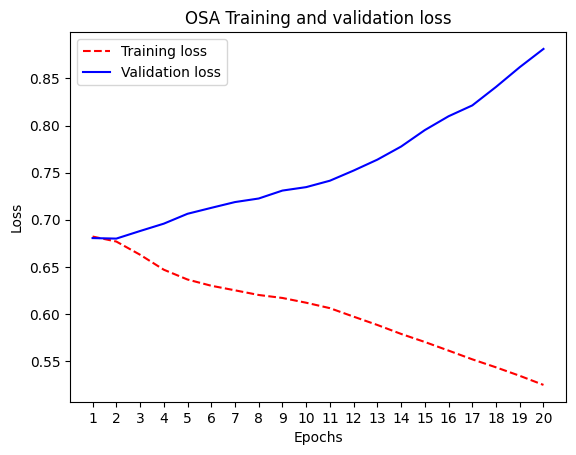

In [27]:
history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1, len(loss_values) + 1)
plt.plot(epochs, loss_values, "r--", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("OSA Training and validation loss")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Loss")
plt.legend()
plt.show()

In [28]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,923,989 (7.34 MB)

 Trainable params: 641,329 (2.45 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,282,660 (4.89 MB)

In [30]:
weights = model.get_layer('embedding').get_weights()[0]
vocab = vectorize_layer.get_vocabulary()

In [31]:
out_v = io.open('vectors.tsv', 'w', encoding='utf-8')
out_m = io.open('metadata.tsv', 'w', encoding='utf-8')

for index, word in enumerate(vocab):
  if index == 0:
    continue  # skip 0, it's padding.
  vec = weights[index]
  out_v.write('\t'.join([str(x) for x in vec]) + "\n")
  out_m.write(word + "\n")
out_v.close()
out_m.close()

In [32]:
try:
  from google.colab import files
  files.download('vectors.tsv')
  files.download('metadata.tsv')
except Exception:
  pass

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>